In [56]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import copy

sys.path.append(os.path.abspath('..'))
from algorithms.auxiliares import *
from algorithms.neural_network import *

In [63]:
class K_fold():
    def __init__(self, modelos, k, muestreo_estratificado=False):
        self.modelos = modelos
        self.k = k
        self.metricas_modelos = []
        self.matrices_confusion = []
        self.muestreo_estratificado = muestreo_estratificado
    
    def cross_val(self, X, y): # Recibe dataset completo
        N = X.shape[0]
        fold_size = N//self.k
        proporcion_test = 1/self.k

        idx = np.arange(N)
        np.random.shuffle(idx)

        self.metricas_modelos = [] # k_i x modelo_i

        for i in range(self.k):                
            if self.muestreo_estratificado:
                if y.ndim > 1:
                    y_labels = np.argmax(y, axis=1)
                else:
                    y_labels = y

                clases = np.unique(y_labels)
                indices = [] # clases x indices? Irregular, es lista
                cant_elementos_test = []

                for clase in clases:
                    idx_clase = np.where(y_labels==clase)[0]
                    indices.append(idx_clase)

                    elemento_test = int(proporcion_test * len(idx_clase))
                    cant_elementos_test.append(elemento_test) 

                idx_select = []

                for idx_clase, n_test in zip(indices, cant_elementos_test):
                    np.random.shuffle(idx_clase)
                    idx_select.extend(idx_clase[:n_test])
                
                idx_select = np.array(idx_select)

                mask = np.ones(N, dtype=bool)
                mask[idx_select] = False
                        
                X_train, X_test = X[mask], X[idx_select]

                if y.ndim == 1:
                    y_test = y[idx_select].reshape(-1,1)
                    y_train = y[mask].reshape(-1,1)
                else:
                    y_test = y[idx_select]
                    y_train = y[mask]
            else:

                idx_select = idx[i*fold_size : (i+1)*fold_size-1]

                mask = np.ones(N, dtype=bool)
                mask[idx_select] = False
                        
                X_train, X_test = X[mask], X[idx_select]

                if y.ndim == 1:
                    y_test = y[idx_select].reshape(-1,1)
                    y_train = y[mask].reshape(-1,1)
                else:
                    y_test = y[idx_select]
                    y_train = y[mask]


            idx = np.arange(X_train.shape[0])
            np.random.shuffle(idx)
            
            metrics = [] 
            cms = []
            for modelo in self.modelos:             
                modelo_copy = copy.deepcopy(modelo)
                modelo_copy.idx_shuffle = idx

                # Ahora si intercambiamos edades -1 por la media
                edad_media = np.mean(X_train[:,33])
                X_train[X_train[:,33] == -1, 33] = edad_media
                X_test[X_test[:,33] == -1, 33] = edad_media

                # Diferentes escalas de datos en features
                media = np.mean(X_train, axis=0)
                std = np.std(X_train, axis=0)
                X_train = (X_train - media) / std
                X_test = (X_test - media) / std

                modelo_copy.fit(X_train, y_train)
                metrica = modelo_copy.score(X_test, y_test)
                metrics.append(metrica)
    #           print(f"K={i}, Métrica: {metrica}")                    
                cm = modelo_copy.confusion_matrix(X_test, y_test)
                cms.append(cm)
    #           print(cm)
    #           print("Sensibilidad:", cm[0,0]/(cm[0,0] + cm[1,0])) # SENSIBILIDAD
    
            self.metricas_modelos.append(metrics)
            self.matrices_confusion.append(cms)

        return np.mean(self.metricas_modelos, axis=1), np.std(self.metricas_modelos, axis=1)


In [58]:
ruta_data = os.path.abspath('../data')

X, y = cargar_datos_csv(os.path.join(ruta_data, 'dermatology.csv'))

X = np.array(X)

# encontrar la moda
valores, counts = np.unique(y, return_counts=True)
moda = valores[np.argmax(counts)]

#print(X[0,:])

# construir array binario
y = (y == moda).astype(int).flatten()
y = 2*y - 1

#print(moda)  
#print(y)  

# El ganador fue psoriasis!!
# Hay 8 personas cuya edad tiene un '?', hice que al importar el dataset
# se ponga -1, así reemplazamos tras splittear con la media.

y = np.array(y)
print(X.shape, y.shape, np.mean(y))

(366, 34) (366,) -0.3879781420765027


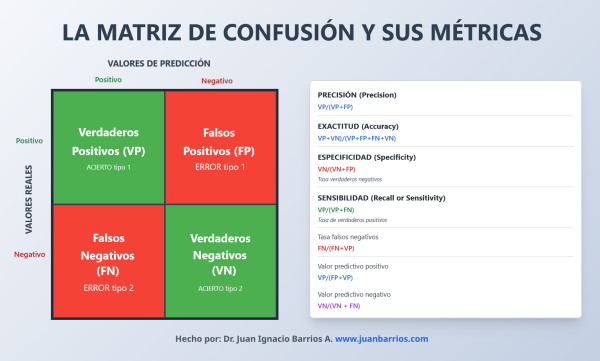

In [59]:
modelos = []
for i in range(3):
    model = neural_network(
        layers_config = [(2, 'symmetry sigmoid'), (1, 'symmetry sigmoid')],
        size_input=X.shape[1],
        max_epoch = 200,
        learning_rate=0.005 + 0.005*i,
        error_threshold=1e-3,
        validation_proportion=0.2,
        paciencia = 20
    )   
    modelos.append(model)

k_fold = K_fold(modelos, k=5, muestreo_estratificado=True)

print(k_fold.cross_val(X,y))

KeyboardInterrupt: 

In [ ]:
print(np.array(k_fold.matrices_confusion))

[[[[51.  0.]
   [ 0. 21.]]

  [[51.  0.]
   [ 0. 21.]]

  [[51.  0.]
   [ 0. 21.]]]


 [[[50.  0.]
   [ 0. 22.]]

  [[50.  0.]
   [ 0. 22.]]

  [[50.  0.]
   [ 0. 22.]]]


 [[[49.  0.]
   [ 1. 22.]]

  [[49.  0.]
   [ 1. 22.]]

  [[49.  0.]
   [ 1. 22.]]]


 [[[52.  0.]
   [ 0. 20.]]

  [[52.  0.]
   [ 0. 20.]]

  [[52.  0.]
   [ 0. 20.]]]


 [[[ 2.  0.]
   [ 0.  0.]]

  [[ 2.  0.]
   [ 0.  0.]]

  [[ 2.  0.]
   [ 0.  0.]]]]


In [ ]:
N = X.shape[0]

idx = np.arange(N)
np.random.shuffle(idx)

idx_select = idx[0:297]

mask = np.ones(N, dtype=bool)
mask[idx_select] = False

X_test, y_test = X[idx_select], y[idx_select].reshape(-1,1)
X_train, y_train = X[mask], y[mask].reshape(-1,1)

# Diferentes escalas de datos en features
media = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)
X_train = (X_train - media) / std
X_test = (X_test - media) / std


In [ ]:
model = neural_network(
    layers_config = [(2, 'symmetry sigmoid'), (2, 'symmetry sigmoid'), (1, 'symmetry sigmoid')],
    size_input=X.shape[1],
    max_epoch = 1000,
    learning_rate=0.01,
    error_threshold=-1e-3,
    validation_proportion=0.2,
    paciencia = 1000
)

model.fit(X_train, y_train)
y_pred = model.transform(X_test)

print(model.score(X_test, y_test))
print(model.confusion_matrix(X_test, y_test))

0.9966329966329966
[[204.   1.]
 [  0.  92.]]


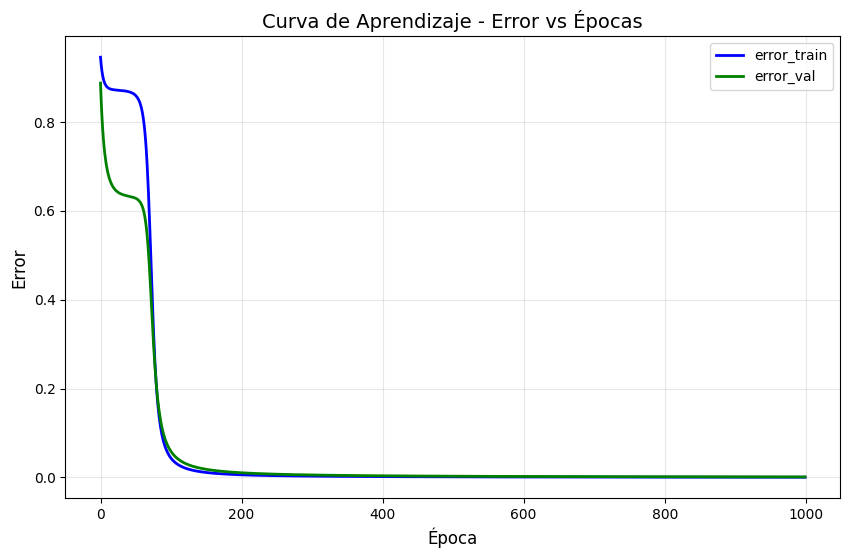

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(model.epoch_error, color='blue', linewidth=2, label='error_train')
plt.plot(model.epoch_error_val, color='green', linewidth=2, label='error_val')
plt.xlabel('Época', fontsize=12)
plt.ylabel('Error', fontsize=12)
plt.title('Curva de Aprendizaje - Error vs Épocas', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Ejercicio 4 con todas las patologías

In [64]:
X, y = cargar_datos_csv(os.path.join(ruta_data, 'dermatology.csv'))

X = np.array(X)

y = np.array(y) - 1 # Así empieza en 0
y = y.flatten()
y = y.astype(int)

n_clases = np.max(y) + 1

Y = -np.ones((len(y), n_clases))
Y[np.arange(len(y)), y] = 1
y = Y

print(X.shape, y.shape)
print(Y)

(366, 34) (366, 6)
[[-1.  1. -1. -1. -1. -1.]
 [ 1. -1. -1. -1. -1. -1.]
 [-1. -1.  1. -1. -1. -1.]
 ...
 [-1. -1.  1. -1. -1. -1.]
 [-1. -1.  1. -1. -1. -1.]
 [ 1. -1. -1. -1. -1. -1.]]


In [65]:
modelos = []
for i in range(3):
    model = neural_network(
        layers_config = [(2, 'symmetry sigmoid'), (6, 'symmetry sigmoid')],
        size_input=X.shape[1],
        max_epoch = 200,
        learning_rate=0.005 + 0.005*i,
        error_threshold=1e-3,
        validation_proportion=0.2,
        paciencia = 20
    )   
    modelos.append(model)

k_fold = K_fold(modelos, k=5, muestreo_estratificado=True)

print(k_fold.cross_val(X,y))

(array([0.84507042, 0.87793427, 0.85446009, 0.87793427, 0.82629108]), array([0.03042601, 0.01756647, 0.026558  , 0.0464765 , 0.02393906]))


In [69]:
print(np.array(k_fold.metricas_modelos))
print(np.mean(k_fold.metricas_modelos, axis=0))
print(np.array(k_fold.matrices_confusion))

[[0.8028169  0.87323944 0.85915493]
 [0.87323944 0.85915493 0.90140845]
 [0.81690141 0.87323944 0.87323944]
 [0.81690141 0.88732394 0.92957746]
 [0.8028169  0.81690141 0.85915493]]
[0.82253521 0.86197183 0.88450704]
[[[[22.  0.  0.  0.  0.  0.]
   [ 1. 11.  0.  0.  0.  0.]
   [ 0.  0. 14.  0.  0.  0.]
   [ 0.  6.  3.  0.  0.  0.]
   [ 0.  0.  0.  0. 10.  0.]
   [ 0.  1.  0.  1.  2.  0.]]

  [[22.  0.  0.  0.  0.  0.]
   [ 1. 11.  0.  0.  0.  0.]
   [ 0.  0. 14.  0.  0.  0.]
   [ 0.  3.  1.  5.  0.  0.]
   [ 0.  0.  0.  0. 10.  0.]
   [ 1.  1.  1.  1.  0.  0.]]

  [[22.  0.  0.  0.  0.  0.]
   [ 2. 10.  0.  0.  0.  0.]
   [ 0.  0. 14.  0.  0.  0.]
   [ 0.  3.  2.  4.  0.  0.]
   [ 0.  0.  0.  0. 10.  0.]
   [ 0.  0.  0.  2.  1.  1.]]]


 [[[22.  0.  0.  0.  0.  0.]
   [ 0. 12.  0.  0.  0.  0.]
   [ 0.  0. 14.  0.  0.  0.]
   [ 0.  4.  1.  4.  0.  0.]
   [ 0.  0.  0.  0. 10.  0.]
   [ 1.  1.  1.  0.  1.  0.]]

  [[22.  0.  0.  0.  0.  0.]
   [ 1. 11.  0.  0.  0.  0.]
   [ 0.  0. 14.  0. 